# STR Matching; AI-assisted coding:
### Data Science for Biology

**Notebook developed by:** *Jeremy Marcus*

**Based on original version by:** *Sarp Dora Kurtoglu; adapted and inspired from Harvard CS50x from 2021 with permission from David Malan.*

**Supervised by:** *Steven Brenner*

___
### AI Overview

#### Use of AI

Throughout this and future labs, we will be explicit about where use of AI is permitted. There will be three possible options, which will be stated up front for each question:

* <font color = #0fd12c>**AI PERMITTED**</font>
* <font color = #d1b70f>**AI REQUIRED**</font>
* <font color = #d14d0f>**NO AI**</font>

Any time you use AI to generate code, ***you are expected to understand what the code is doing***. You may be asked to describe your code.

#### Exporting Chats

When AI tools are used to assist in solving a problem, we will ask for transcripts of any chat sessions as a PDF. Unfortunately, getting Gemini to print a PDF of a chat session while using a CalNet account is not a trivial operation. Here is our suggested solution:

1. Click the `Tools` button at the bottom of the chat box.
2. Select `Canvas`.
3. Copy and paste the following into Gemini:

> Please transcribe our entire conversation word-for-word into a new Canvas document

4. Print to PDF

Alternatively, there are browser-specific extensions that enable chat export. If you choose to use one of these options ***be sure that the extension is one which runs locally, not uploading any data to the cloud***.

___

### Submission requirements:

The following are what you are expected to submit:

* Copy of the `.ipynb` notebook file
* PDF version of the notebook file
    * On the DataHub, choose `Export as WebPDF`
* PDF export of Gemini chat logs (if Gemini was used)

___
### Background

#### Short Tandem Repeats (STRs)
Short tandem repeats (STRs) are short sequences of DNA that repeat *consecutively* at specific locations on the human genome. Within the human population, the numbers of times specific STRs repeat vary greatly, which leads to ways of differentiating people given their STR counts. Different people have each type of STR repeated different numbers of times within their genomes.

For example, in the sequence below, the STR with the sequence "agat" repeats 6 times:

dna = aatgtc<mark>agatagatagatagatagatagat</mark>ccgttga

#### STR Analysis in Forensics
Law enforcement, including FBI, use STR analysis to perform computational forensics analyses and fingerprinting. The FBI uses 20 different CODIS (Combined DNA Index System) loci to perform forensics analyses. In this lab, we will take a simplified approach and explore only a few STR sequences in an unknown individual's DNA sequence.

#### A Simplified Example

As we have discussed in class, forensic STR analysis is currently performed using PCR amplification and gel electrophoresis. This is because these techniques are fast, cheap, easy, and reliable. In this lab, we are asking you to write code for STR analysis of sequenced DNA, as that makes for an interesting coding problem to solve. We will be using only a single strand of DNA, which does not model either biology or CODIS in several ways. For example, the human diploid genome is ~6 billion bases over 46 chromosomes, but here we are giving you only a single sequence.

If you would like to learn more about how STRs are used in forensic analyses by FBI, you can find more details here: https://www.fbi.gov/services/laboratory/biometric-analysis/codis/codis-and-ndis-fact-sheet

___

### The Task in Detail

The primary component of this task is counting the STRs. In this case, since we are taking in sequenced DNA as input, this counting takes the form of string matching.

Suppose we know that an individual has the following STR profile:
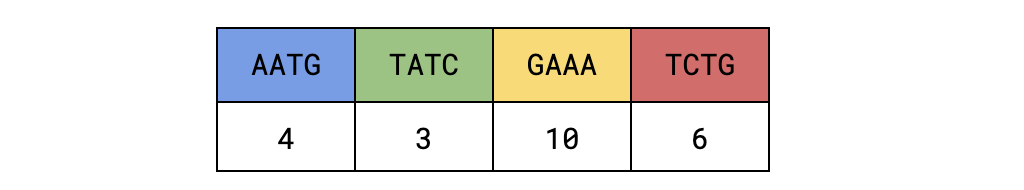

This indicates that somewhere within their genome, they have the following:

* 4 repeats of `AATG` in a row: `AATGAATGAATGAATG`
* 3 repeats of `TATC` in a row: `TATCTATCTATC`
* 10 repeats of `GAAA` in a row: `GAAAGAAAGAAAGAAAGAAAGAAAGAAAGAAAGAAAGAAA`
* 6 repeats of `TCTG` in a row: `TCTGTCTGTCTGTCTGTCTGTCTG`

Note that these repeat runs **may not necessarily be in this order**. For example, the `GAAA` repeats could come earlier in the sequence than the `AATG` repeats.

Given this information, the DNA sequence for this individual might look something like this (left-margin numbers representing genomic position):

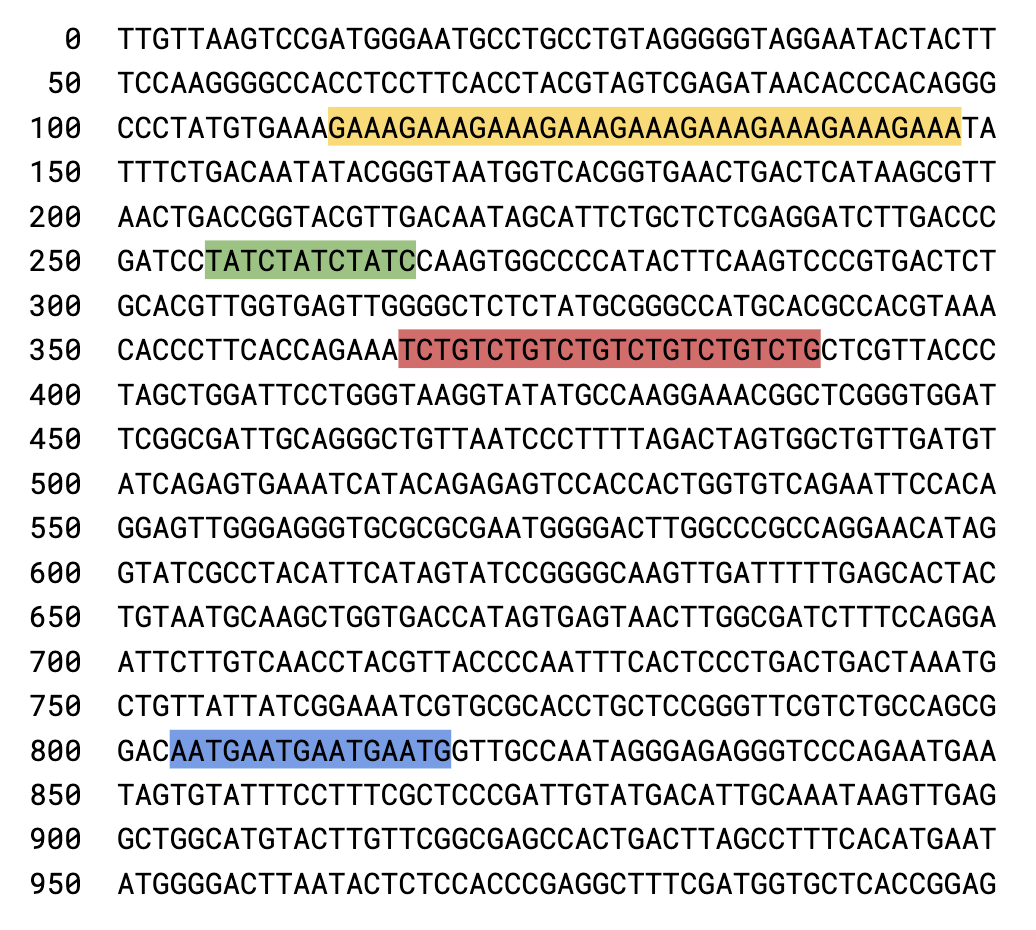

In this image, the repeat runs matching each STR are highlighted. Note that these matches are the **longest** repeat run for each STR. As an example, the `GAAA` sequence appears once in the line labeled 750, but this is a smaller number of repeats than the run on the line labeled 100.

Also, you may assume that none of the repeat runs overlap with one another.

For this task, you will be attempting to recover the STR profile from an input DNA sequence by finding these repeat runs.

For a more detailed breakdown of what this task entails, [you may watch this video](https://www.youtube.com/watch?v=j84b_EgntcQ&t=314s). You only need to watch the end of the video, as the rest contains information that is irrelevant to this assignment.

### The Assignment

You will use Gemini to generate three functions that carry out different parts of this task.

1. **Counting STR repeats**: compute the longest run of consecutive repeats of a given STR within a DNA sequence
2. **Searching the database**: search a database of STR profiles for an exact match to a given STR profile
3. **Pulling it all together**: search a database of STR profiles for any matches to a given DNA sequence

Along the way, you will write test cases to validate your own code **and to perform red-teaming in a future lab**.

In [1]:
# DO NOT CHANGE THIS CELL
import pandas as pd

# Loading the data
database_df = pd.read_csv("Data/large.csv", index_col="name")
with open("Data/sample-dna.txt") as fp:
    dna_seq = fp.read()

The database is a *wide-form table* called `Data/large.csv` structured as follows:
* **index**: names of each individual
* **columns**: STR sequences
* **values**: count of a given STR for a given individual

In [2]:
# DO NOT CHANGE THIS CELL
database_df.head()

,AGATC,TTTTTTCT,AATG,TCTAG,GATA,TATC,GAAA,TCTG
name,,,,,,,,
Albus,15,49,38,5,14,44,14,12
Cedric,31,21,41,28,30,9,36,44
Draco,9,13,8,26,15,25,41,39
Fred,37,40,10,6,5,10,28,8
Ginny,37,47,10,23,5,48,28,23


### Validation Test Runner

We have provided a standardized function that runs user-specified validation tests. You will call this function in your own testing functions. Each call to `test_runner` runs a single test, so you will need to call `test_runner` multiple times in your testing code.

Read the comments inside of the test runner code for more details.

In [1]:
# DO NOT CHANGE THIS CELL
def test_runner(func, test_input: list, expected_output, test_description: str):
    """
    What it does:
        * If the observed output matches the expected output, this function does nothing.
        * If the observed output does not match the expected output, this function prints a helpful log.

    Arguments:
        * func: the name of the function to test
        * test_input: an ordered list of arguments to pass to `func`
        * expected_output: the expected output of running `func` on `test_input` (can pass "ERROR" if a python error is expected to occur)
        * test_description: a helpful description of what this test is doing
    """
    try:
        observed_output = func(*test_input)
    except Exception as e:
        print(repr(e))
        observed_output = "ERROR"
    finally:
        if observed_output != expected_output:
            print(f"FAILED: {test_description}")
            print(f"\tobserved:\t{observed_output}")
            print(f"\texpected:\t{expected_output}")
            print("\tinputs:")
            for x in test_input:
                print(f"\t{x}")
            print("_" * 35)

Below is an example of running a test on the built-in python `round` function.

In [2]:
# DO NOT CHANGE THIS CELL
test_runner(
    func=round,
    test_input=[123.456, 1],
    expected_output=123.5, test_description="Demonstration test"
)

Below is a similar example showing a **failing** test. Note that this test is set up to be ***incorrect*** as a demonstration of the output (compare the `expected_output` parameter to the one above).

In [3]:
# DO NOT CHANGE THIS CELL
test_runner(
    func=round,
    test_input=[123.456, 1],
    expected_output=123, test_description="Demonstration test"
)

FAILED: Demonstration test
	observed:	123.5
	expected:	123
	inputs:
	123.456
	1
___________________________________


___
### Counting STRs

<font color = #d14d0f>**QUESTION 1**:</font> <font color = #d1b70f>**AI REQUIRED**</font>

The first piece of the puzzle is **counting STR repeats**: computing the longest run of consecutive repeats of a given STR within a DNA sequence. To solve this problem, we will build a more generic function that can accept and process any strings (DNA, emojis, uppercase, lowercase, mixed case, etc.)

Using Gemini, create the function `count_repeats_in_string`, which computes the longest run of consecutive repeats of a given substring within a given string. It should take in two strings (in the following order): the string to search through and the substring. The first string is analogous to the DNA sequence to search through, and the substring is analogous to the sequence of a single STR. It should return an integer count of the length of the longest run.

As an example, inputting the sequence pictured above and the substring `AATG` should return `4`.

**NOTE**: For the purposes of this lab, direct Gemini to write code that ***does not use the following***:

* The python `in` operator
* regular expressions

If you have any questions about this restriction, ask a member of the instructional team.

***You should be able to describe how and why this function works.***

In [8]:
def count_repeats_in_string(string: str, substring: str) -> int:
    """
    Computes the longest run of consecutive repeats of a substring 
    within a larger string without using the 'in' operator or regex.
    """
    longest_run = 0
    sub_len = len(substring)
    str_len = len(string)

    # Edge case: if substring is empty, we define the repeat count as 0
    if sub_len == 0:
        return 0

    # Iterate through each possible starting position in the main string
    for i in range(str_len):
        current_run = 0
        
        # Check for consecutive matches starting at index i
        # We use slicing [start:end] to compare strings directly
        while string[i + (current_run * sub_len) : i + (current_run + 1) * sub_len] == substring:
            current_run += 1
        
        # Update the longest run found so far
        if current_run > longest_run:
            longest_run = current_run
            
    return longest_run

<font color = #d14d0f>**QUESTION 2a**:</font> <font color = #d14d0f>**NO AI**</font>
and
<font color = #d14d0f>**QUESTION 2b**:</font> <font color = #d1b70f>**AI REQUIRED**</font>

Write a set of tests to validate the function of `count_repeats_in_string`, using the `test_runner`. Be sure to check both positive and negative test cases.

<font color = #d14d0f>**2a**:</font> First, write a set of validation tests ***without the assistance of AI***. Based on the results of your tests, make any necessary adjustments to the code above.

<font color = #d14d0f>**2b**:</font> Once you are satisfied with the performance based on your own tests, you may ask Gemini to generate more validation tests and make further adjustments.

If the AI comes up with novel validation tests that you did not think of, document them below and describe what they are testing for.

In [ ]:
def test_STR_counting():
    # Example test
    test_runner(
        func=count_repeats_in_string, test_input=["GATCAAAGATC", "AAA"],
        expected_output=1, test_description="Simple repeat matching test"
    )
    # 2a: Tests created WITHOUT AI
    ...
    # 2b: Tests created WITH AI
    ...

In [8]:
# Just run this cell. If there are no outputs, all tests passed.
test_STR_counting()

DOUBLE CLICK HERE TO DOCUMENT AI TESTS

___
### Searching The Database

<font color = #d14d0f>**QUESTION 3**:</font> <font color = #d1b70f>**AI REQUIRED**</font>

Using Gemini, create the function `search_database`, which searches a database of STR profiles for an exact match to a given STR profile. It should take in a `pandas.DataFrame` representing the database and a query list of STR counts. It should return the names of any matching individuals.

**Notes about arguments**

* The index of the `pandas.DataFrame` will contain the names of the individuals.
* You may assume that the query list of STR counts is in the same order as the columns of the `pandas.DataFrame`.

**Notes about return values**
* This method should return a list of names corresponding to any matches. Therefore:
    * If there are no matches, it should return the empty list.
    * If there is one match, it should return a 1-element list.
    * If there are multiple matches, it should return a multi-element list.

***You should be able to describe how and why this function works.***

In [ ]:
def search_database(df: pd.DataFrame, STR_counts: list) -> list:
    pass

<font color = #d14d0f>**QUESTION 4a**:</font> <font color = #d14d0f>**NO AI**</font>
and
<font color = #d14d0f>**QUESTION 4b**:</font> <font color = #d1b70f>**AI REQUIRED**</font>

Write a set of tests to evaluate the function of `search_database`, using the `test_runner`. Be sure to check both positive and negative test cases.

<font color = #d14d0f>**4a**:</font> First, write a set of validation tests ***without the assistance of AI***. Based on the results of your tests, make any necessary adjustments to the code above.

<font color = #d14d0f>**4b**:</font>Once you are satisfied with the performance based on your own tests, you may ask Gemini to generate more tests and make further adjustments.

If the AI comes up with novel tests that you did not think of, document them below and describe what they are testing for.

In [ ]:
def test_database_search():
    # Example test
    test_runner(
        func=search_database, 
        test_input=[pd.DataFrame({"AA": [4,5], "GG": [7, 3]}, index=["person1", "person2"]), [4, 7]],
        expected_output=["person1"], test_description="Simple database search test"
    )
    # 4a: Tests created WITHOUT AI
    ...
    # 4b: Tests created WITH AI
    ...

In [11]:
# Just run this cell. If there are no outputs, all tests passed.
test_database_search()

DOUBLE CLICK HERE TO DOCUMENT AI TESTS

___

### Match DNA Query to Database

<font color = #d14d0f>**QUESTION 5**:</font> <font color = #d1b70f>**AI REQUIRED**</font>

Using Gemini, create the function `STR_search`, which searches a database of STR profiles for any matches to a given DNA sequence. Use the functions `count_repeats_in_string` and `search_database` from above.

It should take in a `pandas.DataFrame` representing the database and a string representing the DNA sequence. It should return a list of matches.

**Notes about inputs**:

* The DNA and the STR sequences may not be in the same case (upper vs. lower); be sure to coerce them to the same case.
* You should validate that both the DNA and the STR sequences are valid DNA

**Notes about repeats**:

* You may assume that none of the repeat runs overlap with one another

***You should be able to describe how and why this function works.***

In [ ]:
def STR_search(database_df: pd.DataFrame, dna_seq: str) -> list:
    pass

<font color = #d14d0f>**QUESTION 6a**:</font> <font color = #d14d0f>**NO AI**</font>
and
<font color = #d14d0f>**QUESTION 6b**:</font>  <font color = #d1b70f>**AI REQUIRED**</font>

Write a set of tests to validate the function of `STR_search`, using the `test_runner`. Be sure to check both positive and negative test cases.

<font color = #d14d0f>**6a**:</font>: First, write a set of tests ***without the assistance of AI***. Based on the results of your tests, make any necessary adjustments to the code above.

<font color = #d14d0f>**6b**:</font>: Once you are satisfied with the performance based on your own tests, you may ask Gemini to generate more tests and make further adjustments.

If the AI comes up with novel tests that you did not think of, document them below and describe what they are testing for.

In [ ]:
def test_STR_search():
    # Example test
    test_runner(
        func=STR_search,
        test_input=[pd.DataFrame({"AA": [4,5], "GG": [7, 3]}, index=["person1", "person2"]), "AAAAAAAAGGGGGGGGGGGGGG"],
        expected_output="person1", test_description="Simple STR search test"
    )
    # 6a: Tests created WITHOUT AI
    ...
    # 6b: Tests created WITH AI
    ...

In [14]:
# Just run this cell. If there are no outputs, all tests passed.
test_STR_search()

DOUBLE CLICK HERE TO DOCUMENT AI TESTS


---

### Congratulations! You have finished the notebook! ##

Don't forget to turn in the following:

* Notebook `.ipynb`
* Notebook `.pdf`
* Gemini chat log `.pdf`

---